# Perceptron

Uses the **Wine dataset** built into Python through `scikit-learn`.

The Wine dataset contains 178 wine samples with 13 numeric chemistry features and 3 cultivar classes. Because the Perceptron is a **binary** classifier, we will explore two strategies:

1. **One-vs-Rest (OvR)** – train one binary Perceptron per class.
2. **Binary subset** – pick two classes and train a single Perceptron directly.



## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Wine Dataset

We use `sklearn.datasets.load_wine()` to access the dataset.

The dataset contains:

- 178 wine samples
- 13 numeric chemistry features
- 3 wine cultivar classes (0, 1, 2)

In [2]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

target_names = data.target_names
class_mapping = {i: name for i, name in enumerate(target_names)}

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClasses:", target_names)
print("\nClass distribution:")
print(y.value_counts().rename(index=class_mapping))

display(X.head())
display(X.describe().T)

Feature matrix shape: (178, 13)
Target shape: (178,)

Classes: ['class_0' 'class_1' 'class_2']

Class distribution:
target
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 3. Exploratory Data Analysis

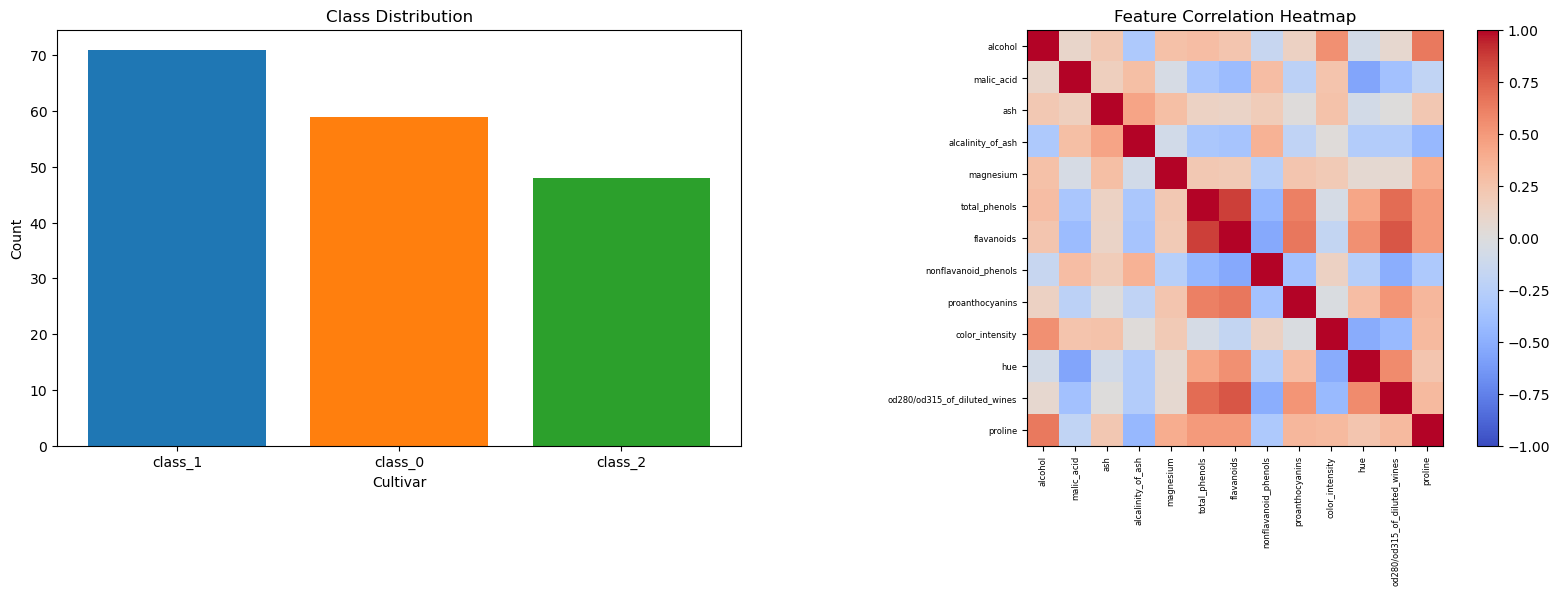

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts = y.map(class_mapping).value_counts()
axes[0].bar(counts.index, counts.values, color=["C0", "C1", "C2"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Cultivar")
axes[0].set_ylabel("Count")

corr = X.corr()
im = axes[1].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=90, fontsize=6)
axes[1].set_yticklabels(corr.columns, fontsize=6)
axes[1].set_title("Feature Correlation Heatmap")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

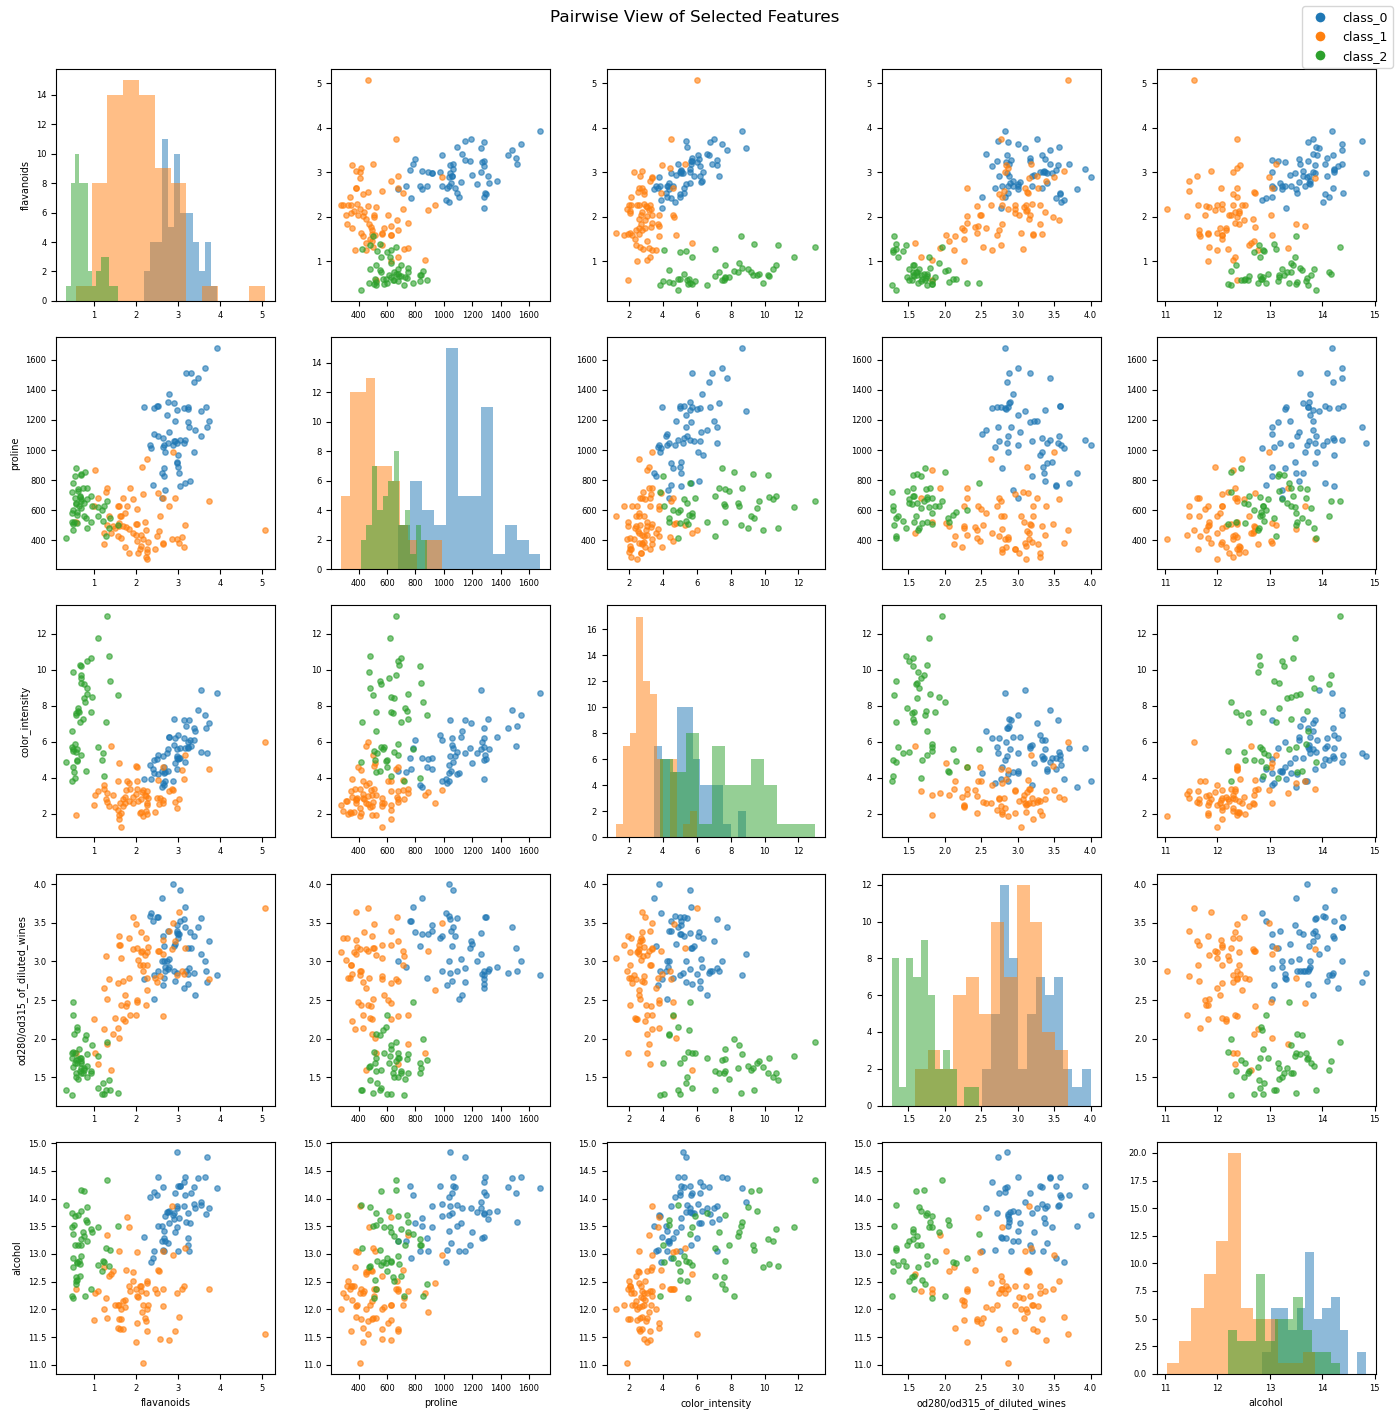

In [4]:
# Scatter matrix of top features coloured by class
top_features = ["flavanoids", "proline", "color_intensity",
                "od280/od315_of_diluted_wines", "alcohol"]

pair_df = X[top_features].copy()
pair_df["target"] = y.values
colors = ["C0", "C1", "C2"]

n = len(top_features)
fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i, fi in enumerate(top_features):
    for j, fj in enumerate(top_features):
        ax = axes[i][j]
        if i == j:
            for cls in range(3):
                mask = pair_df["target"] == cls
                ax.hist(pair_df.loc[mask, fi], bins=12, alpha=0.5,
                        color=colors[cls], label=target_names[cls])
        else:
            for cls in range(3):
                mask = pair_df["target"] == cls
                ax.scatter(pair_df.loc[mask, fj], pair_df.loc[mask, fi],
                           s=15, alpha=0.6, color=colors[cls])
        if i == n - 1:
            ax.set_xlabel(fj, fontsize=7)
        if j == 0:
            ax.set_ylabel(fi, fontsize=7)
        ax.tick_params(labelsize=6)

handles = [plt.Line2D([0],[0], marker="o", color="w",
           markerfacecolor=colors[c], markersize=8,
           label=target_names[c]) for c in range(3)]
fig.legend(handles=handles, loc="upper right", fontsize=9)
plt.suptitle("Pairwise View of Selected Features", y=1.01)
plt.tight_layout()
plt.show()

## 4. Train/Test Split

We use a stratified split to preserve class proportions in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(), y.to_numpy(),
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:    ", X_test.shape,  y_test.shape)

Training set: (142, 13) (142,)
Test set:     (36, 13) (36,)


## 5. Standardize Features

The Perceptron is highly sensitive to feature scale. We standardize using the training set statistics only to avoid data leakage.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training feature means after scaling:")
print(np.round(X_train_scaled.mean(axis=0), 6))
print("\nTraining feature stds after scaling:")
print(np.round(X_train_scaled.std(axis=0), 6))

Training feature means after scaling:
[ 0. -0.  0.  0.  0. -0.  0. -0. -0.  0. -0.  0. -0.]

Training feature stds after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Perceptron Implementation

The Perceptron is the simplest linear classifier. It updates weights only when it makes a mistake:

$$w \leftarrow w - \eta \cdot (\hat{y} - y) \cdot x$$

where $\eta$ is the learning rate, $\hat{y}$ is the prediction, and $y$ is the true label.

Labels must be encoded as **+1 / -1** for the sign activation function.

In [7]:
class Perceptron:
    """
    Binary Perceptron classifier trained with the Perceptron update rule.

    Parameters
    ----------
    eta : float
        Learning rate (step size).
    epochs : int
        Maximum number of passes over the training data.
    random_state : int, optional
        Seed for reproducible weight initialization.
    """

    def __init__(self, eta=0.1, epochs=1000, random_state=42):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state

    def fit(self, X, y):
        """Train on feature matrix X and binary labels y in {-1, +1}."""
        rng = np.random.default_rng(self.random_state)
        # weights[0] = bias; weights[1:] = feature weights
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict_single(xi))
                self.w_[1:] += update * xi
                self.w_[0]  += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            if errors == 0:
                break

        return self

    def net_input(self, X):
        """Compute linear combination of inputs and weights."""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict_single(self, xi):
        """Predict label for a single sample."""
        return 1 if self.net_input(xi) >= 0.0 else -1

    def predict(self, X):
        """Predict labels for all samples in X."""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

## 7. One-vs-Rest (OvR) Multiclass Strategy

Since the Perceptron is binary, we train **one Perceptron per class**. Each Perceptron learns to distinguish its class from all others. At prediction time, we pick the class whose Perceptron fires with the largest net input.

In [8]:
class OvRPerceptron:
    """
    One-vs-Rest wrapper that trains one Perceptron per class.

    Parameters
    ----------
    eta : float
        Learning rate passed to each Perceptron.
    epochs : int
        Max training epochs passed to each Perceptron.
    random_state : int, optional
        Base seed; each binary Perceptron gets a unique seed.
    """

    def __init__(self, eta=0.1, epochs=1000, random_state=42):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = {}

        for i, cls in enumerate(self.classes_):
            # +1 for this class, -1 for all others
            y_binary = np.where(y == cls, 1, -1)
            clf = Perceptron(
                eta=self.eta,
                epochs=self.epochs,
                random_state=self.random_state + i,
            )
            clf.fit(X, y_binary)
            self.classifiers_[cls] = clf

        return self

    def predict(self, X):
        """Predict by taking the class with the highest net input."""
        net_inputs = np.column_stack([
            self.classifiers_[cls].net_input(X)
            for cls in self.classes_
        ])
        return self.classes_[np.argmax(net_inputs, axis=1)]

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

## 8. Train the OvR Perceptron

In [9]:
ovr = OvRPerceptron(eta=0.1, epochs=1000, random_state=42)
ovr.fit(X_train_scaled, y_train)

train_acc = ovr.score(X_train_scaled, y_train)
test_acc  = ovr.score(X_test_scaled,  y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 1.0000
Test  Accuracy: 0.9444


## 9. Test Set Evaluation

In [10]:
y_pred = ovr.predict(X_test_scaled)

print("=" * 50)
print("Classification Report – OvR Perceptron")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report – OvR Perceptron
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



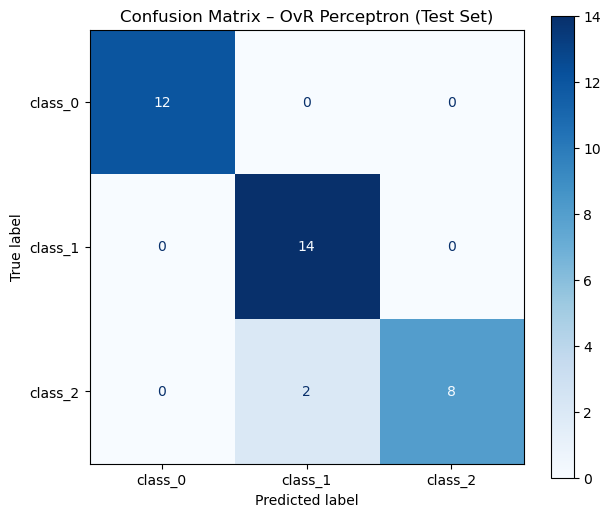

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix – OvR Perceptron (Test Set)")
plt.show()

## 10. Training Error Curves

Each binary Perceptron records how many misclassifications it made per epoch. Convergence to zero errors means a perfect linear separator was found for that one-vs-rest sub-problem.

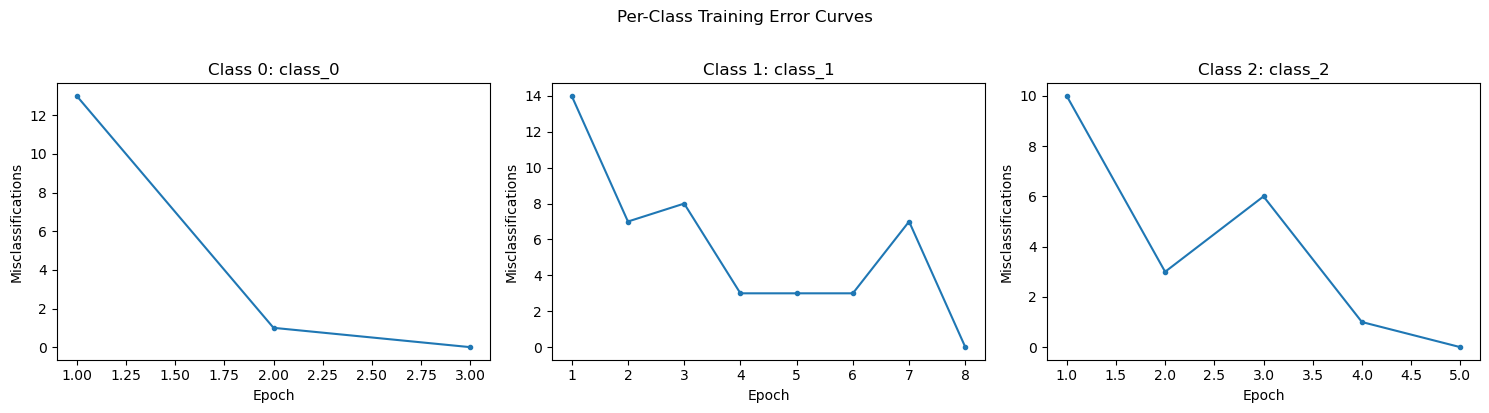

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls in zip(axes, ovr.classes_):
    errors = ovr.classifiers_[cls].errors_
    ax.plot(range(1, len(errors) + 1), errors, marker="o", markersize=3)
    ax.set_title(f"Class {cls}: {target_names[cls]}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Misclassifications")

plt.suptitle("Per-Class Training Error Curves", y=1.02)
plt.tight_layout()
plt.show()

## 11. Decision Boundaries (2-Feature Projection)

We project onto the two most discriminating features (`flavanoids` and `proline`) to visualize the decision boundaries learned by the OvR Perceptron.

In [13]:
feat_indices = [
    data.feature_names.index("flavanoids"),
    data.feature_names.index("proline"),
]
feat_names = [data.feature_names[i] for i in feat_indices]

X_train_2d = X_train_scaled[:, feat_indices]
X_test_2d  = X_test_scaled[:, feat_indices]

ovr_2d = OvRPerceptron(eta=0.1, epochs=2000, random_state=42)
ovr_2d.fit(X_train_2d, y_train)

print(f"2-Feature Train Accuracy: {ovr_2d.score(X_train_2d, y_train):.4f}")
print(f"2-Feature Test  Accuracy: {ovr_2d.score(X_test_2d,  y_test):.4f}")

2-Feature Train Accuracy: 0.8803
2-Feature Test  Accuracy: 0.9444


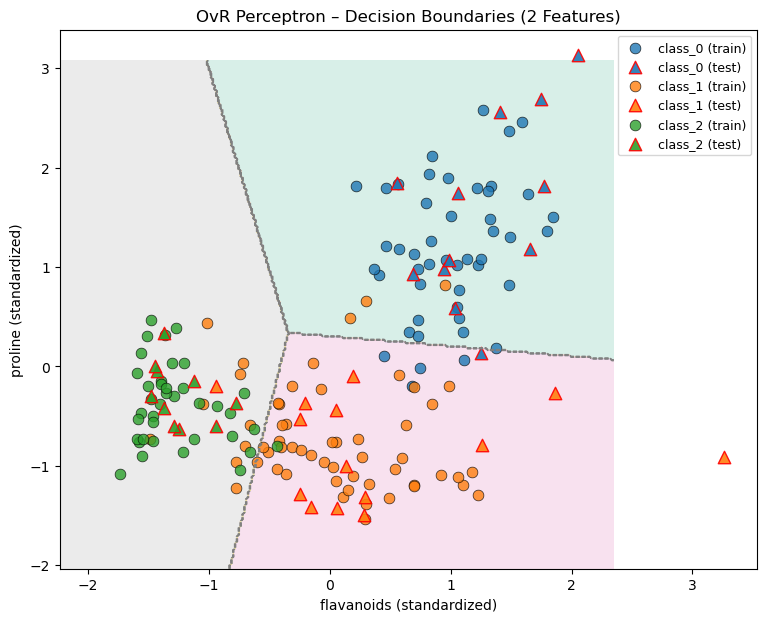

In [14]:
# Build a grid and plot decision regions
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz = ovr_2d.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, zz, alpha=0.25, cmap="Set2")
ax.contour(xx, yy, zz, colors="gray", linewidths=0.8, linestyles="--")

colors = ["C0", "C1", "C2"]
for cls in ovr_2d.classes_:
    mask_tr = y_train == cls
    mask_te = y_test  == cls
    ax.scatter(X_train_2d[mask_tr, 0], X_train_2d[mask_tr, 1],
               label=f"{target_names[cls]} (train)", color=colors[cls],
               edgecolors="black", linewidths=0.5, s=60, alpha=0.8)
    ax.scatter(X_test_2d[mask_te, 0],  X_test_2d[mask_te, 1],
               label=f"{target_names[cls]} (test)",  color=colors[cls],
               edgecolors="red",   linewidths=1.0, s=80, marker="^", alpha=0.9)

ax.set_xlabel(feat_names[0] + " (standardized)")
ax.set_ylabel(feat_names[1] + " (standardized)")
ax.set_title("OvR Perceptron – Decision Boundaries (2 Features)")
ax.legend(loc="upper right", fontsize=9)
plt.show()

## 12. Binary Perceptron on Two Classes

We train a single Perceptron on classes 0 and 1 only to illustrate the pure binary case. Labels are encoded as +1 / -1.

In [15]:
# Filter to classes 0 and 1
mask_train = y_train != 2
mask_test  = y_test  != 2

X_bin_train = X_train_scaled[mask_train]
y_bin_train = np.where(y_train[mask_train] == 0, 1, -1)

X_bin_test = X_test_scaled[mask_test]
y_bin_test = np.where(y_test[mask_test]  == 0, 1, -1)

print("Binary train samples:", X_bin_train.shape[0])
print("Binary test  samples:", X_bin_test.shape[0])

Binary train samples: 104
Binary test  samples: 26


Binary Train Accuracy: 1.0000
Binary Test  Accuracy: 1.0000


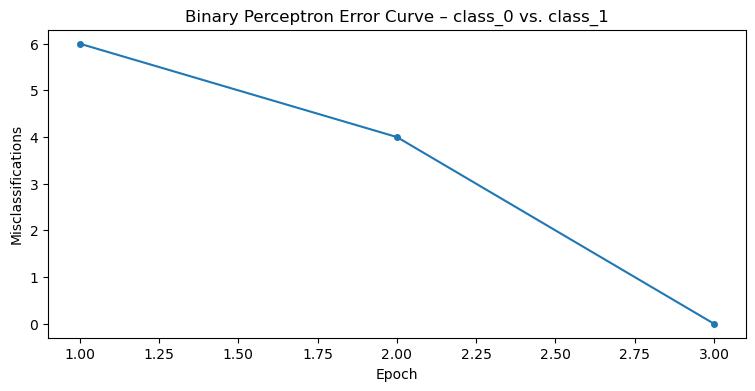

In [16]:
binary_clf = Perceptron(eta=0.1, epochs=1000, random_state=42)
binary_clf.fit(X_bin_train, y_bin_train)

bin_train_acc = accuracy_score(y_bin_train, binary_clf.predict(X_bin_train))
bin_test_acc  = accuracy_score(y_bin_test,  binary_clf.predict(X_bin_test))

print(f"Binary Train Accuracy: {bin_train_acc:.4f}")
print(f"Binary Test  Accuracy: {bin_test_acc:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(binary_clf.errors_) + 1), binary_clf.errors_, marker="o", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title(f"Binary Perceptron Error Curve – {target_names[0]} vs. {target_names[1]}")
plt.show()

## 13. Effect of Learning Rate (`eta`)

We sweep `eta` and record the final test accuracy of the OvR Perceptron to understand its sensitivity to this hyperparameter.

,eta,Train Accuracy,Test Accuracy,Max Epochs Used
0,0.0001,1.0,0.944444,15
1,0.0010,1.0,0.944444,13
2,0.0100,1.0,0.972222,7
3,0.0500,1.0,0.972222,5
4,0.1000,1.0,0.944444,8
5,0.5000,1.0,0.972222,9
6,1.0000,1.0,0.972222,9


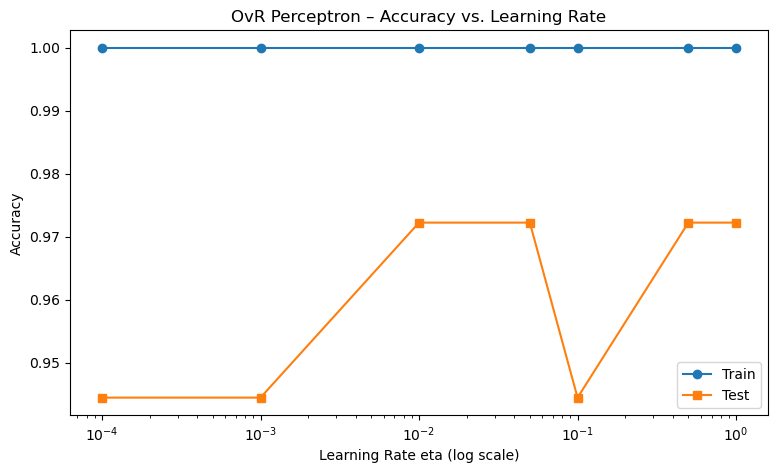

In [17]:
etas   = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
rows   = []

for eta in etas:
    model = OvRPerceptron(eta=eta, epochs=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    rows.append({
        "eta":            eta,
        "Train Accuracy": model.score(X_train_scaled, y_train),
        "Test Accuracy":  model.score(X_test_scaled,  y_test),
        "Max Epochs Used": max(len(model.classifiers_[c].errors_) for c in model.classes_),
    })

eta_df = pd.DataFrame(rows)
display(eta_df)

plt.figure(figsize=(9, 5))
plt.semilogx(eta_df["eta"], eta_df["Train Accuracy"], marker="o", label="Train")
plt.semilogx(eta_df["eta"], eta_df["Test Accuracy"],  marker="s", label="Test")
plt.xlabel("Learning Rate eta (log scale)")
plt.ylabel("Accuracy")
plt.title("OvR Perceptron – Accuracy vs. Learning Rate")
plt.legend()
plt.show()

## 14. Weight Interpretation

Because the features were standardized, each weight $w_j$ reflects the relative importance of feature $j$ for separating that class from the rest. Larger absolute values indicate more influential features.

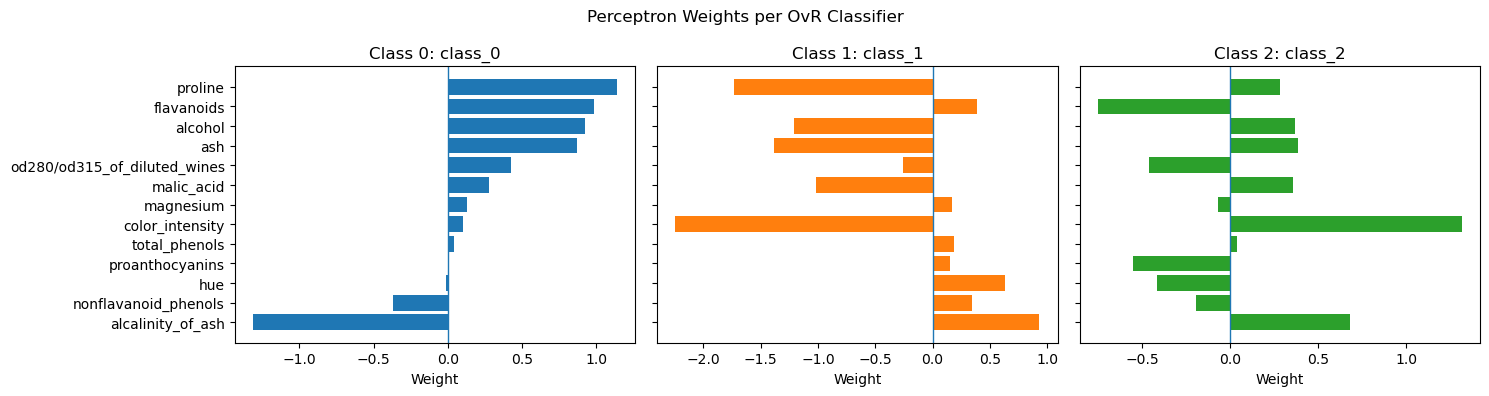

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, cls in zip(axes, ovr.classes_):
    clf   = ovr.classifiers_[cls]
    coefs = clf.w_[1:]          # skip bias
    sorted_idx = np.argsort(coefs)
    ax.barh(
        [data.feature_names[i] for i in sorted_idx],
        coefs[sorted_idx],
        color=f"C{cls}",
    )
    ax.axvline(0, linewidth=1)
    ax.set_title(f"Class {cls}: {target_names[cls]}")
    ax.set_xlabel("Weight")

plt.suptitle("Perceptron Weights per OvR Classifier")
plt.tight_layout()
plt.show()